# Initialization

In [8]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn
import duckdb

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

### Combining the recent_tables and its audio features

In [2]:
df_all = pd.read_sql("""
WITH track_artist_genres AS (
  SELECT
    rta.track_id,
    rta.collection_date,
    string_agg(DISTINCT rta.artist_id::text, ', ') AS artist_ids,
    string_agg(DISTINCT rta.artist_name, ', ') AS artist_names,
    string_agg(DISTINCT ag.genres, ', ') AS artist_genres
  FROM recent_track_artists rta
  LEFT JOIN artist_genres ag
    ON ag.id = rta.artist_id
   AND ag.collection_date = rta.collection_date
  GROUP BY rta.track_id, rta.collection_date
)

SELECT
  a.*,
  r.track_name,
  r.album_name,
  r.artist_name,
  tag.artist_ids,
  tag.artist_names,
  tag.artist_genres

FROM recent_tracks_audio_features a

JOIN recent_tracks r
  ON a.id = r.track_id
 AND a.collection_date = r.collection_date

LEFT JOIN track_artist_genres tag
  ON tag.track_id = r.track_id
 AND tag.collection_date = r.collection_date;
""", engine)

### Analyzing daily listening volume

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='collection_date'>

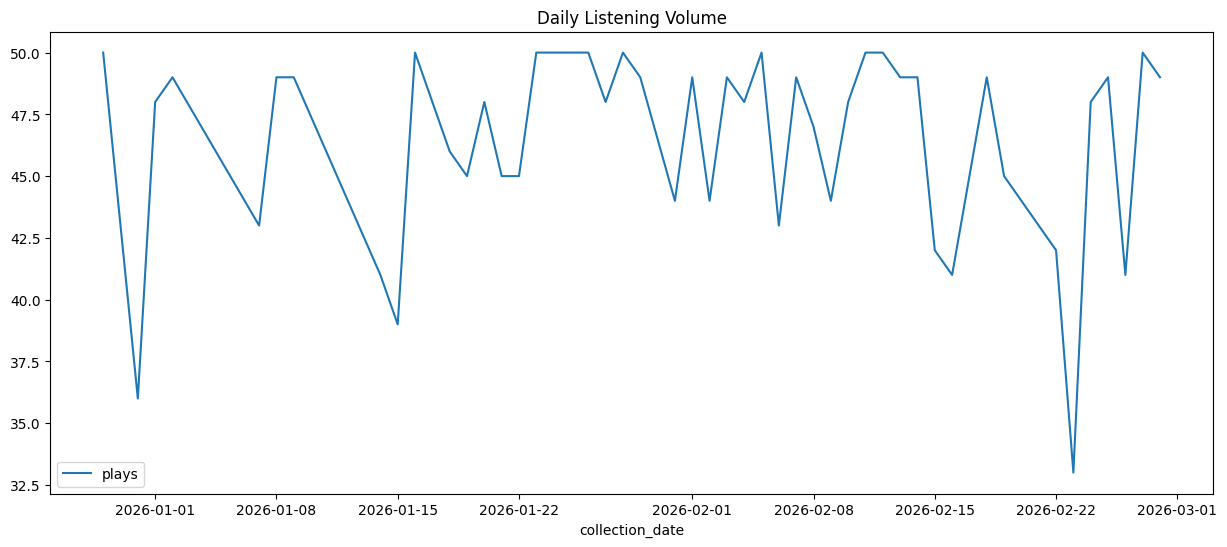

In [3]:
df = pd.read_sql("""
SELECT collection_date, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY collection_date
ORDER BY collection_date
""", engine)

df.plot(x="collection_date", y="plays", title="Daily Listening Volume", figsize=(15, 6))

In [4]:
df.describe()

,plays
count,50.000000
mean,46.500000
std,3.939595
min,33.000000
25%,44.250000
50%,48.000000
75%,49.000000
max,50.000000


From the graph, we can see that the plays are typically around 50 with the max being 50 plays a day and a mean of 46 plays a day. The lowest amount of plays per day was 36. The max no. of tracks you can get from Spotify API is also 50 tracks.

### Analyzing number of unique plays

We want to look at the unique number of tracks played per day to see if the user is repeating listening or exploring new songs often.

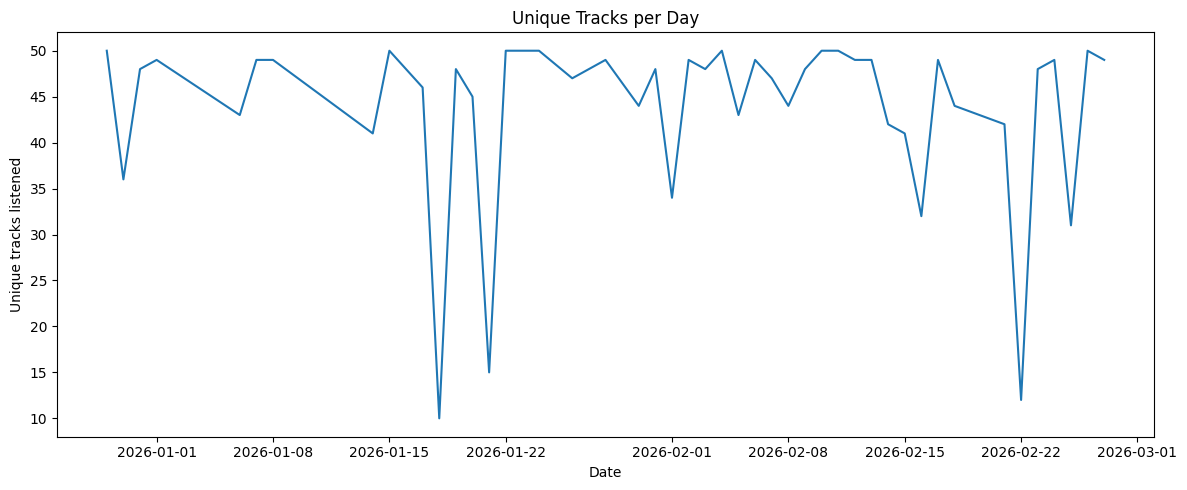

In [5]:
df = pd.read_sql("""
SELECT
    played_at::date AS day,
    COUNT(DISTINCT track_id) AS unique_tracks
FROM recent_tracks
WHERE played_at >= '2025-12-29'
GROUP BY day
ORDER BY day;
""", engine)

plt.figure(figsize=(12, 5))
plt.plot(df["day"], df["unique_tracks"])
plt.xlabel("Date")
plt.ylabel("Unique tracks listened")
plt.title("Unique Tracks per Day")
plt.tight_layout()
plt.show()

This is another plot of unique plays across the user's whole listening history and not just per day.

<Axes: title={'center': 'New (Globally Unique) Tracks per Day'}, xlabel='day'>

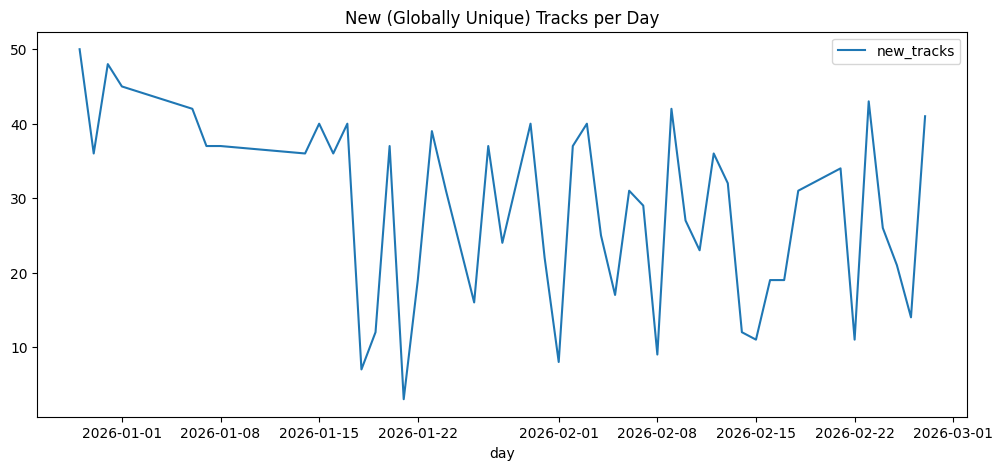

In [6]:
df = pd.read_sql("""
    SELECT track_id, played_at::date AS day
    FROM recent_tracks
    WHERE played_at IS NOT NULL AND played_at >= '2025-12-29'
""", engine)

df["first_day"] = df.groupby("track_id")["day"].transform("min")

new_tracks_per_day = (
    df[df["day"] == df["first_day"]]
    .groupby("day")["track_id"]
    .nunique()
    .reset_index(name="new_tracks")
)


new_tracks_per_day.plot(
    x="day",
    y="new_tracks",
    figsize=(12, 5),
    title="New (Globally Unique) Tracks per Day"
)


We can see that the user explores new tracks often.

### Exploring recent top tracks and artists

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='track_name'>

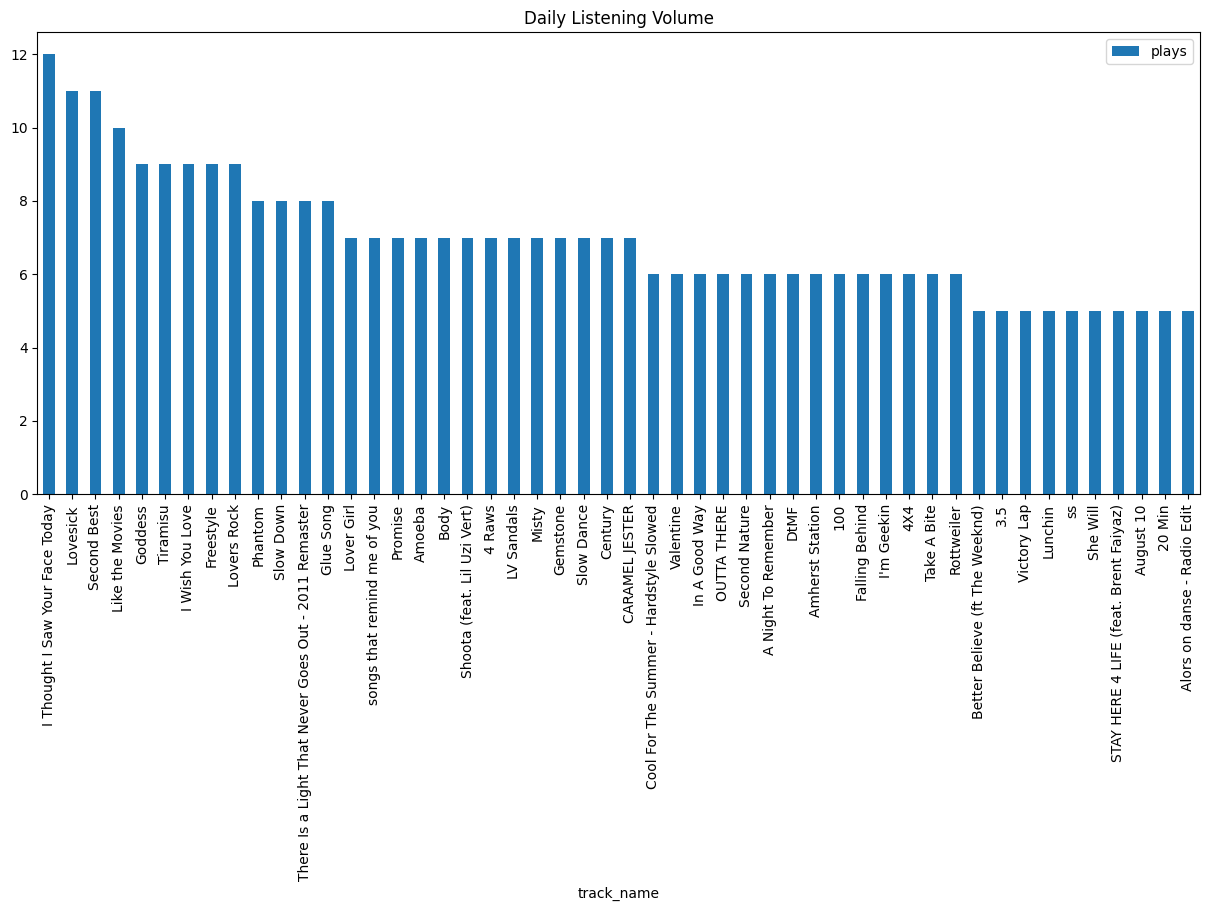

In [7]:
df = pd.read_sql("""
SELECT track_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY track_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
# df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="track_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


<Axes: title={'center': 'Daily Listening Volume'}, xlabel='artist_name'>

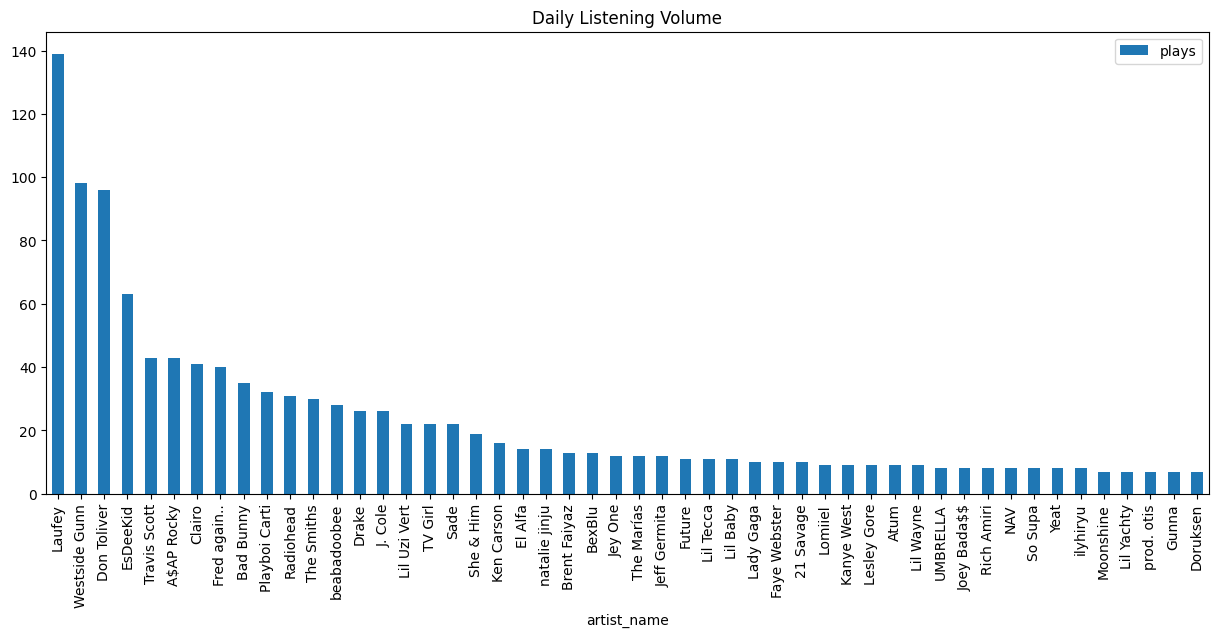

In [ ]:
df = pd.read_sql("""
SELECT artist_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY artist_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="artist_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


<Axes: title={'center': 'Daily Listening Volume'}, xlabel='artist_genres'>

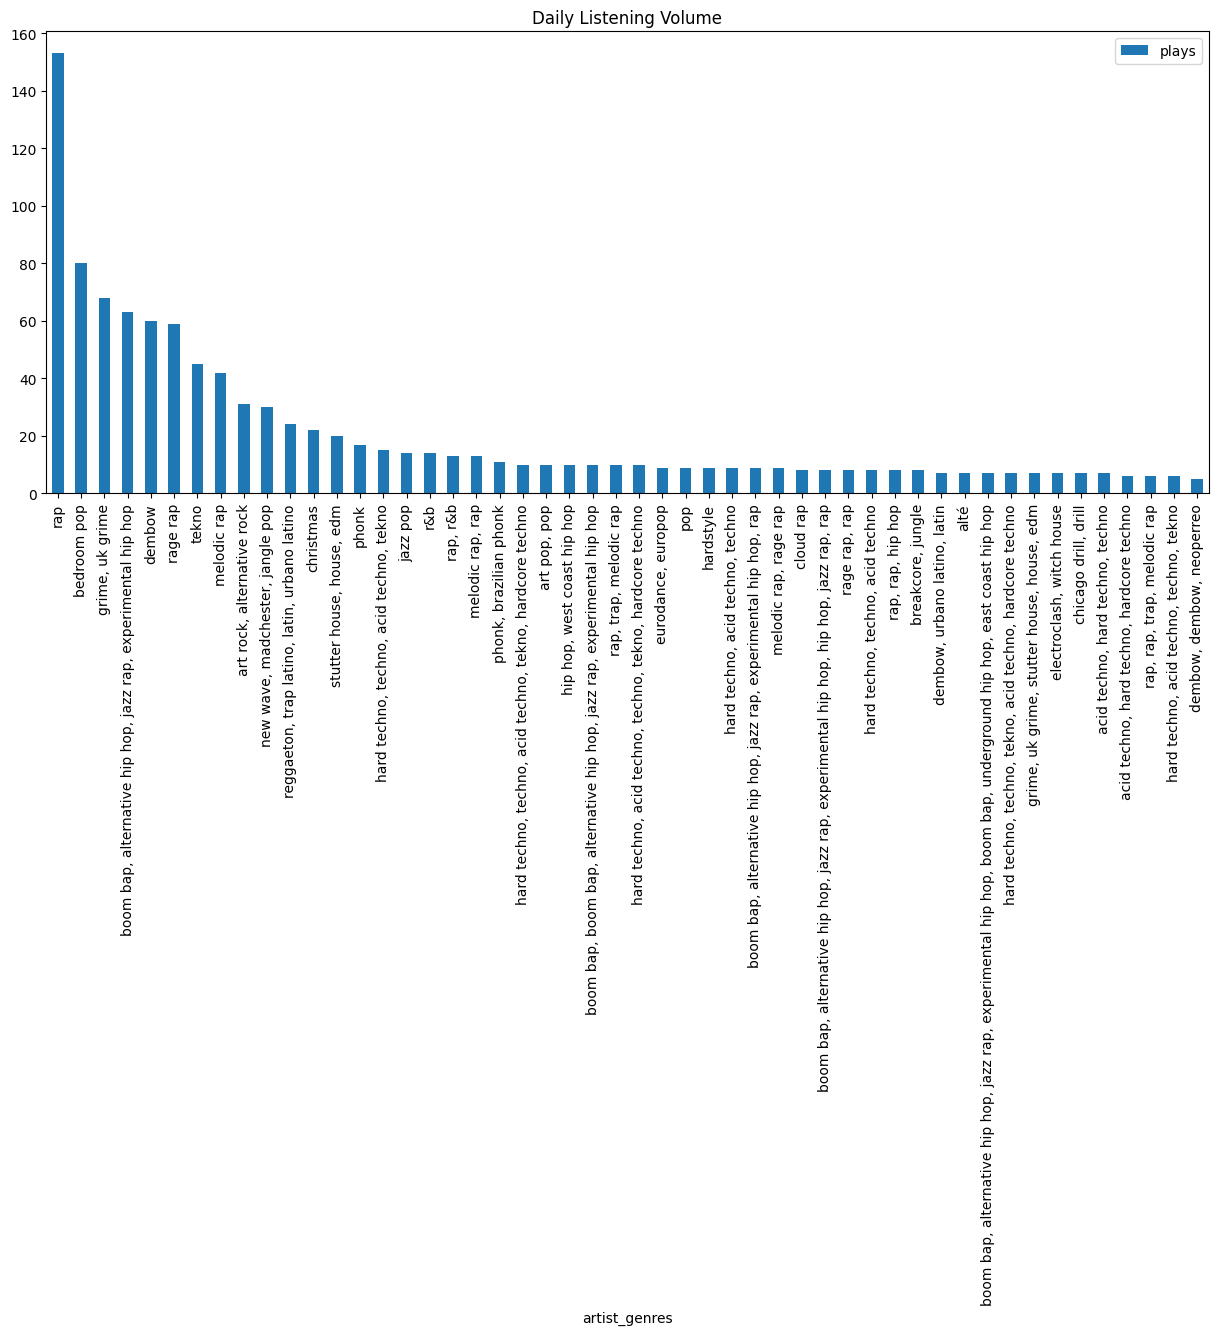

In [12]:
query = """
SELECT artist_genres, COUNT(*) AS plays
FROM read_csv_auto('../data/raw/df_all.csv')
WHERE collection_date >= '2025-12-29' AND artist_genres IS NOT NULL
GROUP BY artist_genres
ORDER BY plays DESC
LIMIT 50;
"""

# for artists with $ in their names
# df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df = duckdb.query(query).to_df()

df.plot(
    x="artist_genres",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


### Audio Features Distributions

(-0.5, 1.5)

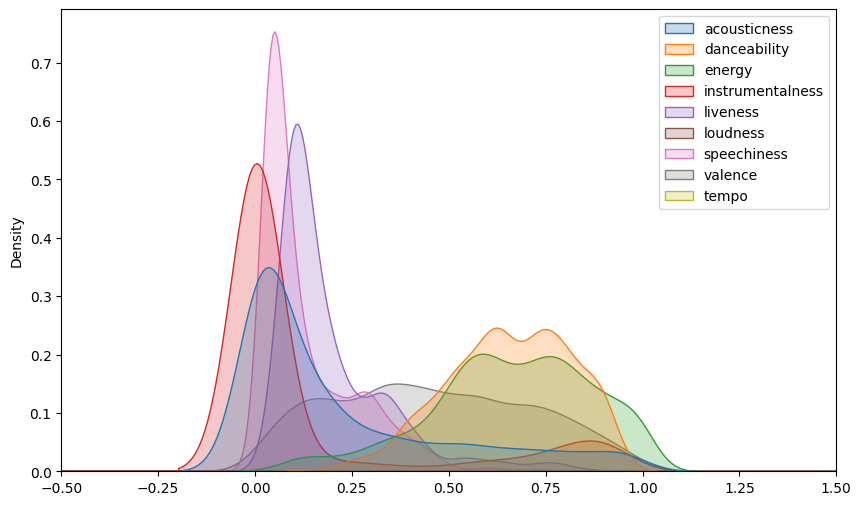

In [9]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "valence", "tempo"
]

df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[features], fill=True) # for kde plot
plt.xlim(-0.5, 1.5)

array([[<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>]], dtype=object)

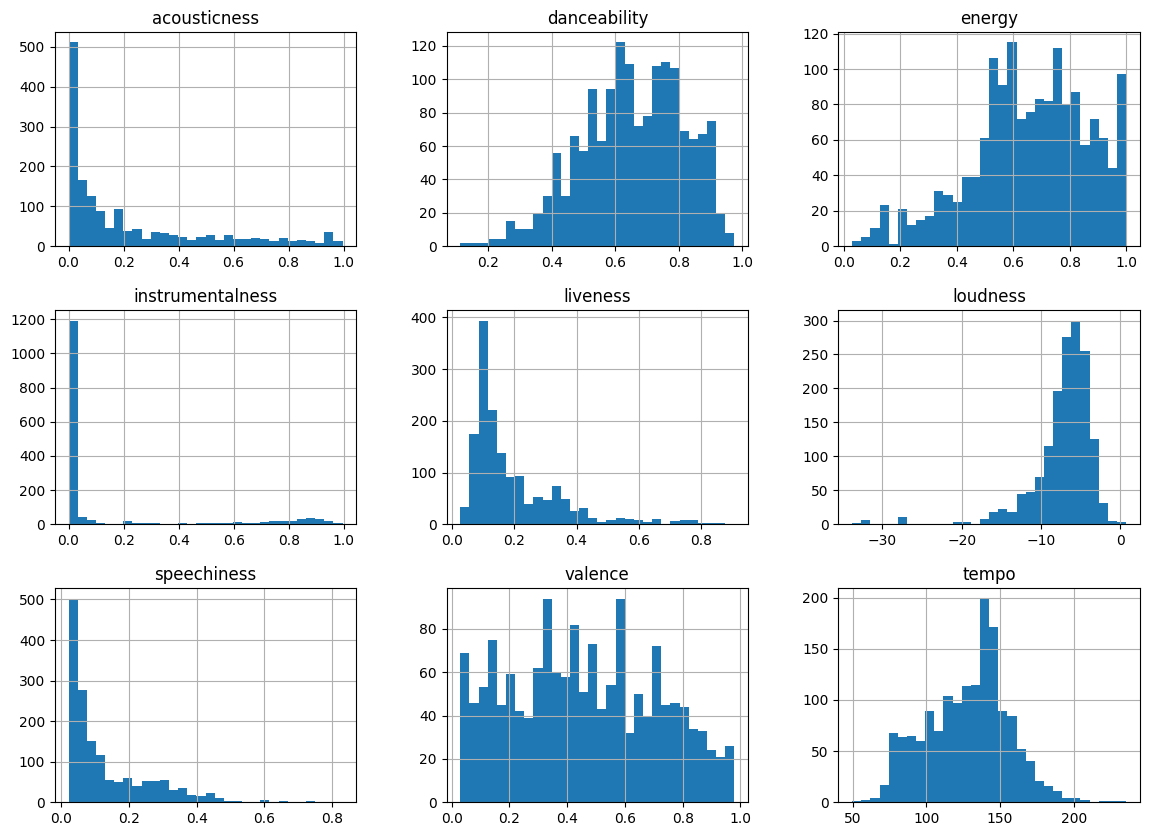

In [10]:
df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))
# sns.kdeplot(data=df[features], fill=True) # for kde plot

In [11]:
df[features].corr().round(2)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
acousticness,1.00,-0.27,-0.54,-0.17,-0.09,-0.49,0.03,0.06,-0.25
danceability,-0.27,1.00,0.06,-0.21,-0.05,0.27,0.13,0.33,0.02
energy,-0.54,0.06,1.00,0.32,0.21,0.64,0.01,0.16,0.22
instrumentalness,-0.17,-0.21,0.32,1.00,-0.06,-0.09,-0.19,-0.30,0.18
liveness,-0.09,-0.05,0.21,-0.06,1.00,0.14,0.15,0.01,0.01
loudness,-0.49,0.27,0.64,-0.09,0.14,1.00,-0.08,0.20,0.14
speechiness,0.03,0.13,0.01,-0.19,0.15,-0.08,1.00,0.20,0.12
valence,0.06,0.33,0.16,-0.30,0.01,0.20,0.20,1.00,-0.04
tempo,-0.25,0.02,0.22,0.18,0.01,0.14,0.12,-0.04,1.00


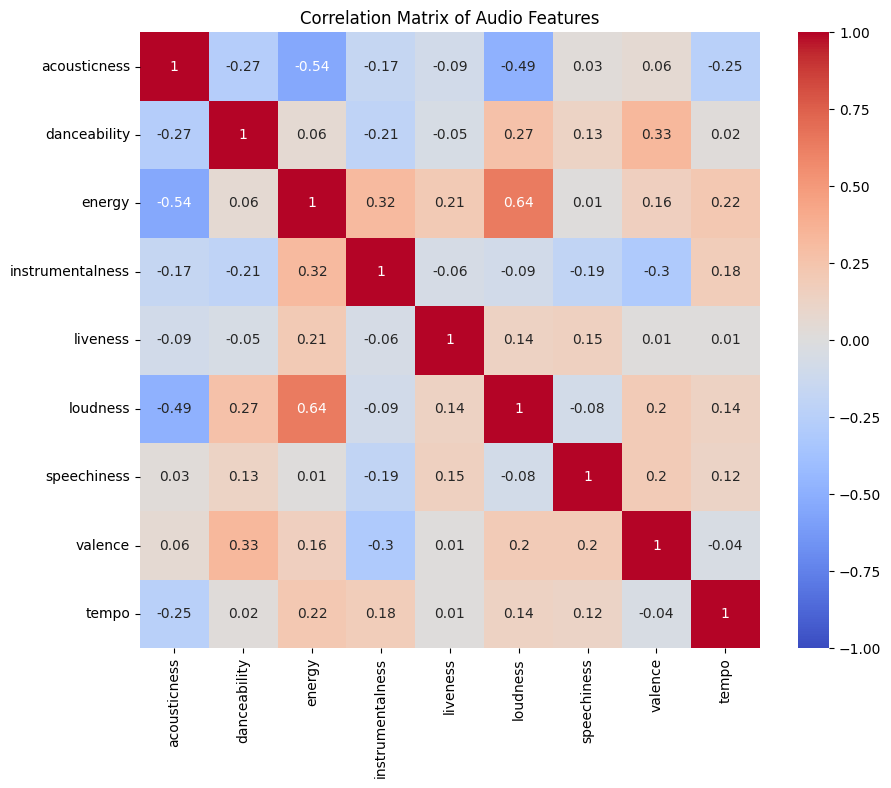

In [12]:
df_corr = df[features].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Audio Features")
plt.show()

### PCA

In [13]:
X = df[features]
# print(X)
# X = X[~pd.isnull(X).any(axis=1)]  # Remove rows with NaN values
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# df["pca_1"] = X_reduced[:, 0]
# df["pca_2"] = X_reduced[:, 1]

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.26682925 0.19350918]
0.46033842851409934


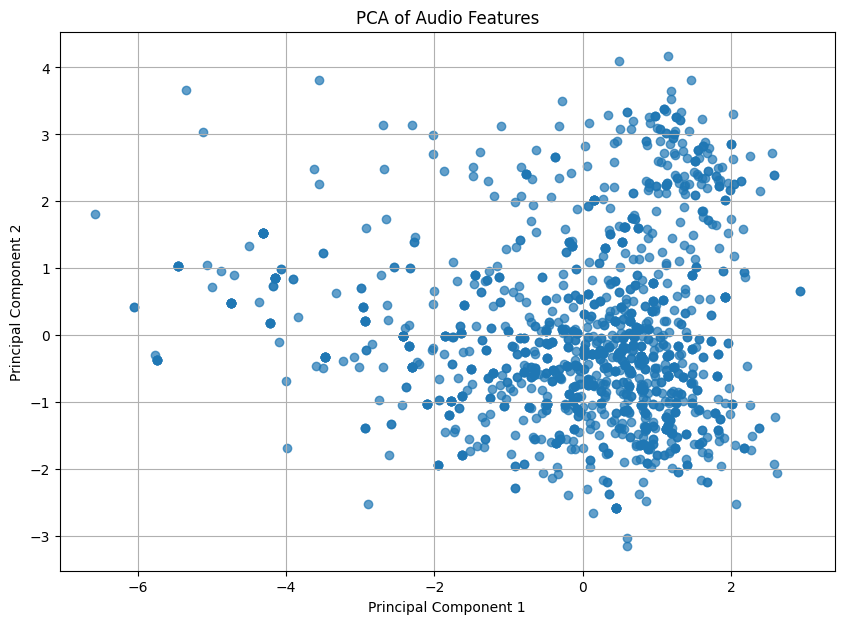

In [14]:

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha =0.7)
plt.title("PCA of Audio Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

### Mood clustering — make clusters easy to review

This section is designed to help you **inspect and name** a small number of clusters (e.g. **k = 4**) by:

- **Quantitatively** comparing a few candidate `k` values (inertia, silhouette, Davies–Bouldin)
- Training the final KMeans model
- Showing:
  - **Cluster counts**
  - **Centroids in original units** (human-readable)
  - **Radar plots in standardized units** (z-scores)
  - **Representative tracks per cluster** (most recent + closest-to-centroid)

After reviewing, manually name each cluster (see the template below).

In [15]:
# (Old exploratory run)
# The cluster review workflow starts below and will fit KMeans for the chosen K.
# This cell is intentionally left as a no-op to avoid confusion.

,k,inertia,silhouette,davies_bouldin
0,2,12086.469143,0.196514,2.316353
1,3,9710.823896,0.247132,1.505691
2,4,8836.954617,0.163924,1.880780
3,5,8021.339409,0.171160,1.694820
4,6,7383.078575,0.184286,1.545123
5,7,6892.712674,0.186675,1.537923
6,8,6569.350661,0.189006,1.564726
7,9,6190.935746,0.186490,1.546173
8,10,6049.233817,0.179335,1.619240


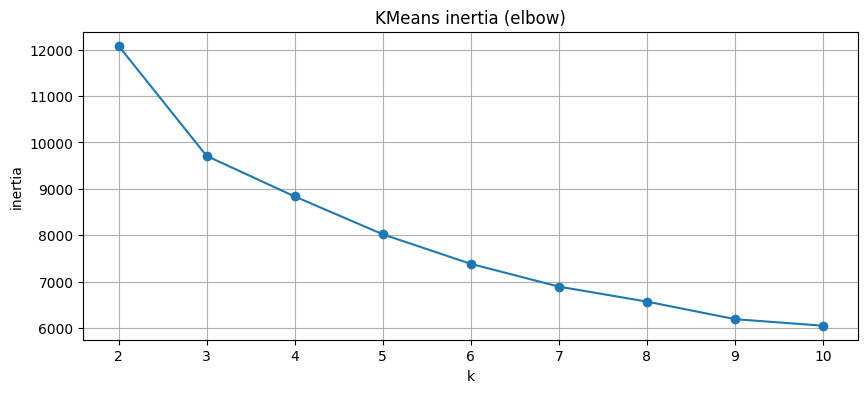

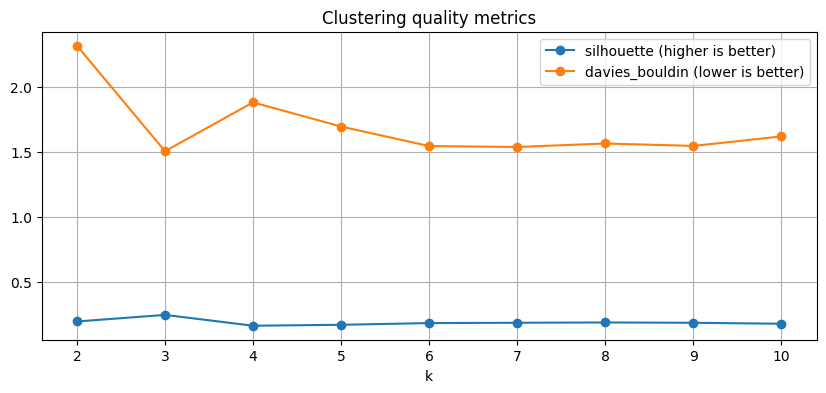

In [16]:
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Quick model selection helper (keep this lightweight; you’ll still pick K manually).
K_RANGE = range(2, 11)

rows = []
for k in K_RANGE:
    km = sklearn.cluster.KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
    })

scores = pd.DataFrame(rows).sort_values("k")
display(scores)

plt.figure(figsize=(10, 4))
plt.plot(scores["k"], scores["inertia"], marker="o")
plt.title("KMeans inertia (elbow)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(scores["k"], scores["silhouette"], marker="o", label="silhouette (higher is better)")
plt.plot(scores["k"], scores["davies_bouldin"], marker="o", label="davies_bouldin (lower is better)")
plt.title("Clustering quality metrics")
plt.xlabel("k")
plt.grid(True)
plt.legend()
plt.show()

Cluster counts
cluster
0    583
1    498
2    221
3    264
Name: count, dtype: int64


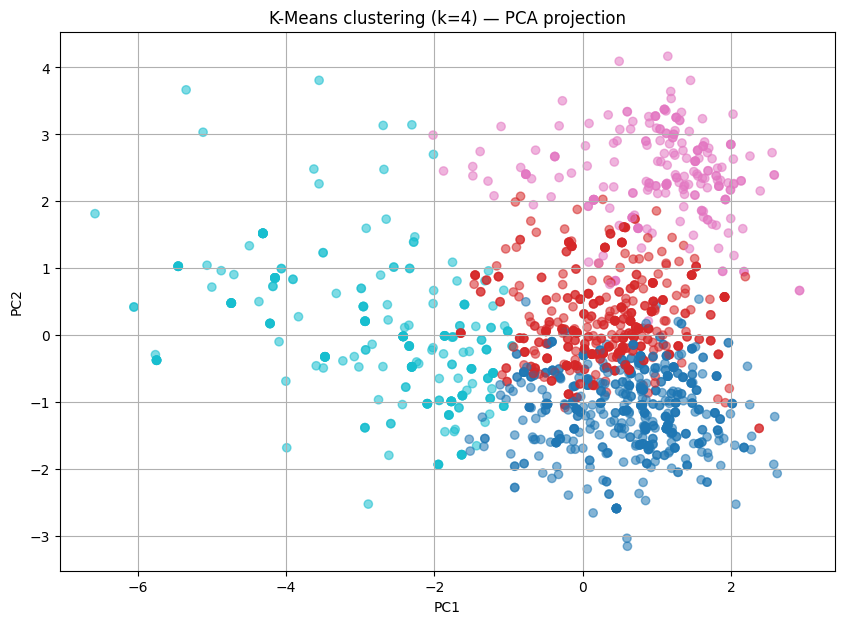

In [17]:
# Final choice for inspection (you can change this, but keep it small for interpretability).
K = 4

model = sklearn.cluster.KMeans(n_clusters=K, random_state=42, n_init="auto")
clusters = model.fit_predict(X_scaled)

# Attach cluster ids back to the cleaned feature rows.
# NOTE: X was built from df[features].dropna(), so X.index maps back to df.
df_cluster = df.loc[X.index].copy()
df_cluster["cluster"] = clusters

print("Cluster counts")
print(df_cluster["cluster"].value_counts().sort_index())

# Optional quick visualization (PCA already computed above)
plt.figure(figsize=(10, 7))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='tab10', alpha=0.55)
plt.title(f"K-Means clustering (k={K}) — PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [18]:
# Centroids in standardized feature space (z-scores)
centroids_scaled = pd.DataFrame(model.cluster_centers_, columns=features)

# Centroids in original feature units (human-readable)
centroids_unscaled = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=features,
)

# display(centroids_unscaled)

# Quick per-cluster feature summary (original units)
display(df_cluster.groupby("cluster")[features].mean().sort_index())

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
cluster,,,,,,,,,
0,0.180313,0.756127,0.701768,0.014496,0.180841,-5.947240,0.198644,0.658599,130.985762
1,0.103739,0.636378,0.673341,0.014336,0.247404,-5.989478,0.089482,0.328354,126.340323
2,0.057894,0.578507,0.873412,0.791538,0.185386,-6.942828,0.081354,0.272337,143.285389
3,0.675628,0.529481,0.365112,0.084561,0.148492,-12.624830,0.112418,0.409954,111.365663


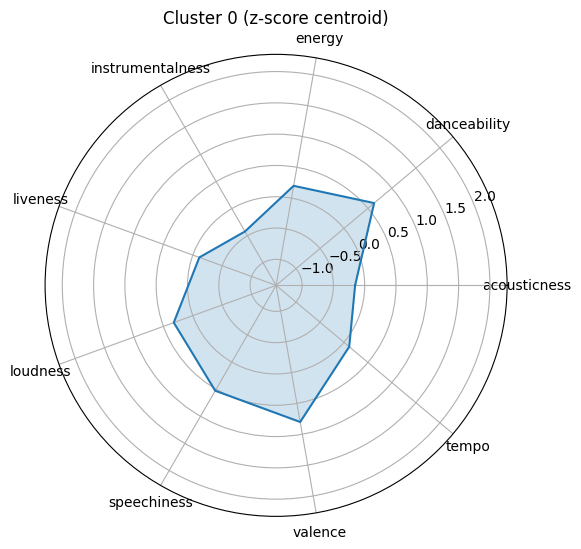

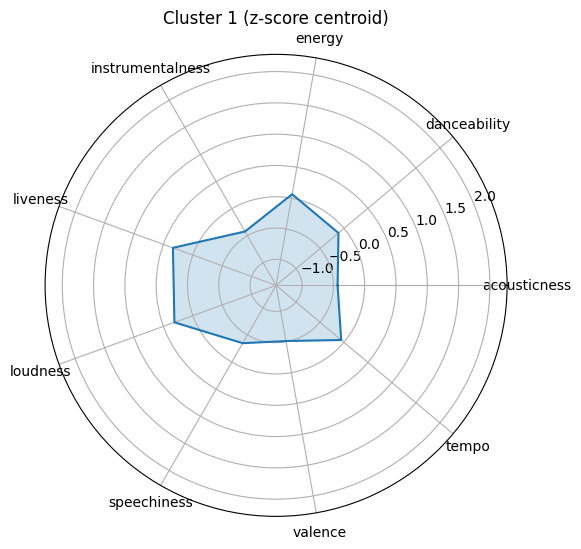

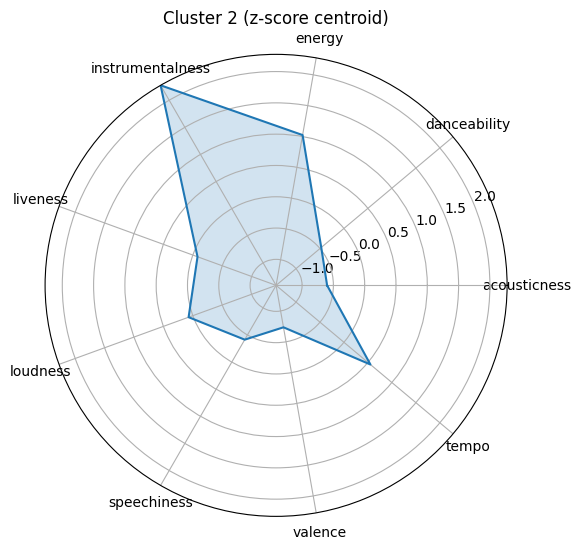

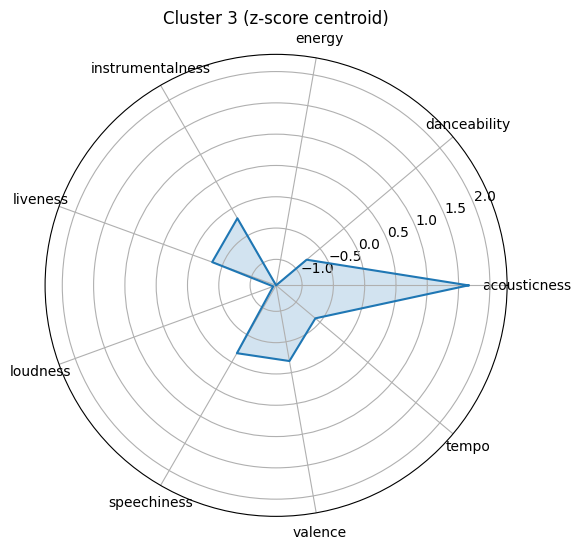

In [19]:
import numpy as np

# Radar plots use standardized centroids so features are comparable.
# Positive values = above your personal mean; negative = below.

def radar_plot(row, title, *, vmin=None, vmax=None):
    values = row.values.tolist()
    values += values[:1]

    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.20)
    ax.set_thetagrids(np.degrees(angles[:-1]), features)
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)
    plt.title(title)
    plt.show()

# Use global min/max so all cluster plots share a consistent scale.
plot_vmin = float(np.min(centroids_scaled.to_numpy()))
plot_vmax = float(np.max(centroids_scaled.to_numpy()))

for cid in range(K):
    radar_plot(centroids_scaled.iloc[cid], f"Cluster {cid} (z-score centroid)", vmin=plot_vmin, vmax=plot_vmax)

In [20]:
# Representative tracks per cluster

def _display_cols(df_):
    preferred = [
        "collection_date",
        "name",
        "track_name",
        "artist",
        "artists",
        "id",
        "track_id",
    ]
    return [c for c in preferred if c in df_.columns]

sample_cols = _display_cols(df_cluster)

if "collection_date" in df_cluster.columns:
    df_cluster["collection_date"] = pd.to_datetime(df_cluster["collection_date"], errors="coerce")

for cid in range(K):
    print("\n" + "=" * 80)
    print(f"Cluster {cid}")

    cdf = df_cluster[df_cluster["cluster"] == cid]

    # Most recent listens in this cluster (if available)
    if "collection_date" in cdf.columns:
        recent = cdf.sort_values("collection_date", ascending=False).head(15)
        print("Most recent tracks")
        display(recent[sample_cols] if sample_cols else recent.head(15))

    # Closest-to-centroid tracks (typical examples) — restrict within cluster
    centroid = model.cluster_centers_[cid]
    mask = (clusters == cid)
    dists = np.linalg.norm(X_scaled[mask] - centroid, axis=1)
    local_idx = np.argsort(dists)[:15]

    typical = df_cluster[mask].iloc[local_idx].copy()
    print("Closest to centroid (typical tracks)")
    display(typical[sample_cols] if sample_cols else typical.head(15))


Cluster 0
Most recent tracks


,collection_date,name,id
2157,2026-02-22,NIGHTS LIKE THIS,1XBYiRV30ykHw5f4wm6qEn
2131,2026-02-22,NEW DROP,2c7z5oRcPBbqRaBY2mLWcf
2114,2026-02-22,DtMF,3sK8wGT43QFpWrvNQsrQya
2115,2026-02-22,Last of the Mohicans,417YLEvDX9igfVVam9Q9r2
2119,2026-02-22,BABY I'M BACK,5kDgJffgJ0lYHTSiaXFWNw
2120,2026-02-22,WELTiTA,5WEF0icHWmAZBBMglBd599
2122,2026-02-22,CARAMEL JESTER,2Emg9UfihjAkFU3mlal2i9
2124,2026-02-22,MUTT,2uvE4L5ZsYKpv8hbK4TIOt
2125,2026-02-22,KEHLANI,3bWEONUAlVrGAB4NqQiT2R
2126,2026-02-22,GIRLS,3Fra5SMXXDTSRXVoDf8Xwd


Closest to centroid (typical tracks)


,collection_date,name,id
2046,2026-02-18,Stuff (feat. Travis Scott),6JvIjI8H3yxpigROd3Cv9N
527,2026-01-16,KICK OUT,5P03xImM2uFukzoty7NDw7
21,2026-01-01,ruff sqwad and ting,7pkCRAM1ftScTqtVUFaNbd
2031,2026-02-18,Erase Your Social,4uhvMW7ly7tJil31YYscAN
1807,2026-02-13,Paranoid Android,6LgJvl0Xdtc73RJ1mmpotq
1937,2026-02-16,Victory Lap,1lbNgoJ5iMrMluCyhI4OQP
190,2026-01-02,Raving On The Cloud - Original Mix,67oaIM4WXv8xYYZiMtVNXz
462,2026-01-14,I Don't Like,1h6kgem1ai8vUgO1rZOwfB
1721,2026-02-11,ROI Hardstyle - slowed,6DhXDcI7fmjgfChkciqAro
1426,2026-02-05,STAY HERE 4 LIFE (feat. Brent Faiyaz),2xsTsnA5QOFCnFXdEHGkli



Cluster 1
Most recent tracks


...

,collection_date,name,id
1093,2026-01-28,Das Gift,0NiTV6CShCCRjvy3grv8LN
189,2026-01-02,EYE444EYE,7391Z6nQjzlb2tD2huulBn
230,2026-01-08,Ghost Town,3Hzn0Ow4z874WYWeBnkyDb
187,2026-01-02,"yes, please",7MQqgBOLisu7Ndz6tYFbvW
1098,2026-01-28,Ready - Hard Techno Mix,0w3uKrQXk948YwATI7yUbd
1746,2026-02-12,Money Longer,0B8QzDH7YWih85V5SEMnyJ
1005,2026-01-26,OUTTA THERE,2dETM1UnYgkRncciMUMNQV
955,2026-01-25,OUTTA THERE,2dETM1UnYgkRncciMUMNQV
941,2026-01-25,Discombobulate,1CQsMYsorYYZt1Wjrec0ph
991,2026-01-26,Discombobulate,1CQsMYsorYYZt1Wjrec0ph



Cluster 3
Most recent tracks


,collection_date,name,id
2150,2026-02-22,Or What,0CFhbNsY7CsuSkBQOiLPzz
2149,2026-02-22,Drip Too Hard (Lil Baby & Gunna),78QR3Wp35dqAhFEc2qAGjE
2024,2026-02-18,Doja,3LtpKP5abr2qqjunvjlX5i
1986,2026-02-17,wrong faces.,0yYTRodDOWqZZ0AWa2qxHH
1983,2026-02-17,butterflies.,4jyyma8YdFC4S4llusSFRu
1981,2026-02-17,strangers.,2zsqco8LaRPjSJ2K8KbyDZ
1976,2026-02-17,WY@,3ria9Axw5mheRAOoP9bnof
1975,2026-02-17,BOTHER ME (feat. Brent Faiyaz),5vCNxnIZH8KoxtAn7I7qg0
1974,2026-02-17,VIBES DON'T LIE,1WwrfoGe0K33z1tVI6mevJ
1973,2026-02-16,Es un Secreto,3KZCP2StVGdWkOKyRZNWA4


Closest to centroid (typical tracks)


,collection_date,name,id
435,2026-01-14,Nope your too late i already died,0hta2Lb2zKJ7kEnAEZEE3G
476,2026-01-15,Cry Me A River,7xsrfbE3uNQgXoUl0t1TmO
1546,2026-02-07,Lovers Rock,6dBUzqjtbnIa1TwYbyw5CM
845,2026-01-23,Real Life,3HVRZxCp3BWYuYe8L8BMNH
708,2026-01-20,The Fly who couldn't Fly straight (feat. Tyler...,6bCbBTw3mqHWQwhFMMaOOq
796,2026-01-22,Second Best,4Y9Ge3i5r0vgFAZq653Yx3
1478,2026-02-06,Goddess,2SEeyc2KS9DIjiJPCYtfgJ
1143,2026-01-29,Coming Home,36FgNo5lmrUUSrDqXJLsrz
1842,2026-02-14,CARAMEL JESTER,2Emg9UfihjAkFU3mlal2i9
1975,2026-02-17,BOTHER ME (feat. Brent Faiyaz),5vCNxnIZH8KoxtAn7I7qg0


### Manual mood names (k=4)

Use the **centroid tables**, **radar plots**, and **sample tracks** above to manually name each cluster.

Fill these in once you’re happy with the cluster separation:

- **Cluster 0**: _TODO name_
- **Cluster 1**: _TODO name_
- **Cluster 2**: _TODO name_
- **Cluster 3**: _TODO name_

Notes:
- The radar plots are in **standardized units (z-scores)**, so features are comparable.
- The centroid table is in **original units**, which is better for intuition (tempo BPM, loudness dB, etc.).
- If the clusters look “mixed”, try adjusting `K` (3–5) and rerun the cluster review cells.

### Genre analysis

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

alpha = 0.7          # audio weight
svd_dim = 25         # genre embedding size

# Align genres to the same rows as X (X came from df[features].dropna())
genre_text = df.loc[X.index].get("artist_genres", "").fillna("").astype(str)

# TF-IDF over genre tokens (comma-separated)
tfidf = TfidfVectorizer(
    tokenizer=lambda s: [t.strip().lower() for t in s.split(",") if t.strip()],
    preprocessor=lambda s: s,
    token_pattern=None,
    min_df=2,         # ignore super-rare genres
)

G = tfidf.fit_transform(genre_text)

svd = TruncatedSVD(n_components=svd_dim, random_state=42)
G_svd = svd.fit_transform(G)

G_scaled = StandardScaler().fit_transform(G_svd)

X_combined = np.hstack([alpha * X_scaled, (1 - alpha) * G_scaled])

model = sklearn.cluster.KMeans(n_clusters=K, random_state=42, n_init="auto")
clusters = model.fit_predict(X_combined)

AttributeError: 'str' object has no attribute 'fillna'